In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

# GOAL: to fit spectra in a window around the line. Use XSpec to fit

I only use 1 power-law+ gaussians. The goal is to check if this works for E>2 keV

Here I load the data 

In [2]:
AllData.clear()
path="/home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
#filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
#fileRMF=path+"srctoolout_120_RMF_00001.fits"
#fileARF=path+"srctoolout_120_ARF_00001.fits"
filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
#
filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
#
filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
#
filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
#
filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
#
filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
#
#Put here the TM you want to use 
#
vfilespectrum = [filespectrumTM1 ]
vfileRMF = [fileRMFTM1]
vfileARF = [fileARFTM1 ]
# vfilespectrum = [filespectrumTM4]
# vfileRMF = [fileRMFTM4]
# vfileARF = [fileARFTM4]
#
#LOAD DATA
#

#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).multiresponse[0] = vfileRMF[plot_grp]
    AllData(plot_grp+1).multiresponse[0].arf = vfileARF[plot_grp]
    AllData(plot_grp+1).multiresponse[1] = vfileRMF[plot_grp] # RMF only for src2

AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 9.345e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.
Response successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /home/jortecal/GitHub/eRosita/LMC3Deg_JorgePC/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channe

Error: cannot read response file srctoolout_120_RMF_00001.fits


In [3]:
# PLOT of Aeff for various telescopes

#fig, ax = plt.subplots(figsize=(10,6))
#for i in range (0,len(vfileARF)):
#    arf1test = fits.open(vfileARF[i])['SPECRESP']
#    arf1ELOW = arf1test.data.field('ENERG_LO')#keV
#    arf1EHI = arf1test.data.field('ENERG_HI')#keV
#    arf1Aeff = arf1test.data.field('SPECRESP')#cm2
#    arf1E = (arf1ELOW + arf1EHI)/2.
#    ax.plot(arf1E, arf1Aeff,label='TM')
#ax.set_xlabel('Energy (keV)')
#ax.set_ylabel(r'A_{eff} [cm^2]')
#ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_xlim((0.8,1.5))
#ax.grid()
#ax.legend()

NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [3]:
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 4.771 #6.266

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  4.771  sigma  0.050468744932550026
Emin  4.51865627533725  Emax  5.02334372466275
**-4.5187,,5.0233-**
Plot command list is now empty
NEbins  43
***************
Selected values  4.524918794631958   5.011302709579468  Nbins  43
***************
   519 channels (1-519) ignored in spectrum #     1
   462 channels (563-1024) ignored in spectrum #     1

Min Max counts  49   89


In [5]:
print("sigma ",sigma)
print("DeltaE ",vedeltas[0]*2)
print("Sigma/DeltaE ",sigma/(vedeltas[0]*2))

sigma  0.050468744932550026
DeltaE  [0.0114274  0.0114336  0.01144218 0.01144934 0.01145697 0.01146412
 0.01147175 0.0114789  0.01148605 0.01149368 0.01150084 0.01150846
 0.01151609 0.01152325 0.01152945 0.01153708 0.01154566 0.01155186
 0.01155949 0.01156616 0.01157522 0.01158047 0.0115881  0.01159573
 0.0116024  0.01161003 0.01161814 0.01162386 0.01163149 0.01163912
 0.01164627 0.01165247 0.01166105 0.01166677 0.01167536 0.01168203
 0.01168919 0.01169586 0.01170349 0.01170969 0.0117178  0.01172495
 0.01173162]
Sigma/DeltaE  [4.4164669  4.41407246 4.41076135 4.40800589 4.40507052 4.40232216
 4.39939435 4.39665307 4.3939152  4.39099856 4.38826773 4.38535858
 4.38245329 4.37973307 4.37737828 4.37448355 4.37123154 4.36888588
 4.36600237 4.36348241 4.36006712 4.35809229 4.355223   4.35235749
 4.34985325 4.3469948  4.3439618  4.34182341 4.3389755  4.33613132
 4.33346828 4.33116296 4.32797503 4.32585235 4.32267222 4.32020202
 4.31755851 4.31509415 4.31228118 4.30999835 4.30701674 4.30438934

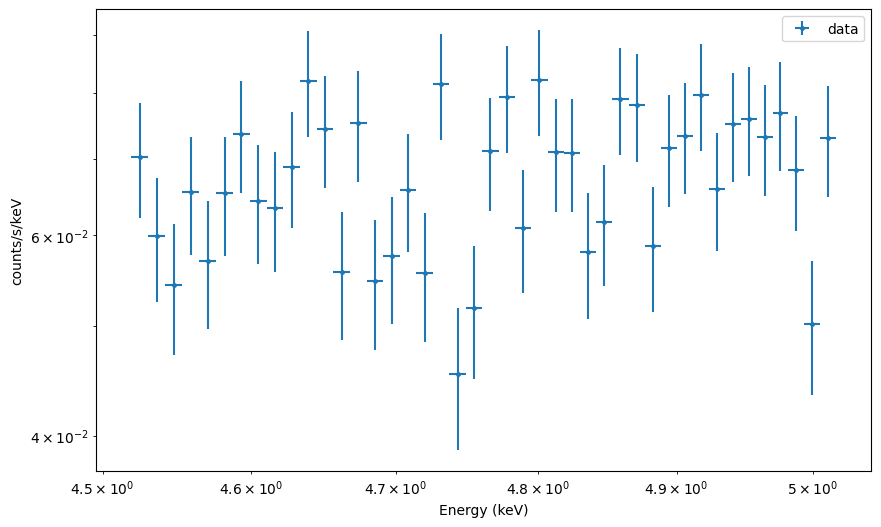

In [6]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [7]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/home/jortecal/GitHub/eRosita/3MLFits/MarcoFitsMay/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]


ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  1  IB  1  A  0
[4.51187]
[4.49]   [4.53]


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [8]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model
# with paramers value params, name (gaussian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target

class MTmodel:
    def __init__(self, model, params_name, params_target, fit):
        self.model = model
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile fast setters for just the main value (index 0 of .values)
        self._param_fast_setters = [
            self._make_fast_setter(getattr(getattr(model, name), attr))
            for name, attr in zip(params_name, params_target)
        ]

        # Also keep full parameter objects for set_values_all
        self._param_objects = [
            getattr(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_fast_setter(self, param_obj):
        def setter(value, param_obj=param_obj):
            #param_obj.values[0] = value
            param_obj.values = value
        return setter

    #set value of parameters
    def set_values(self, params):
        for setter, value in zip(self._param_fast_setters, params):
            setter(float(value))  # direct, fast assignment

    #set value of parameters including upper/lower limits
    def set_values_all(self, params, lowers, uppers):
        for i, param in enumerate(self._param_objects):
            a = float(params[i])
            b = float(lowers[i])
            c = float(uppers[i])
            param.values = [a, 1e-2 * a, b, b, c, c]

    # evaluate TS given paramaters params
    def evaluate_folded(self, params):
        self.set_values(params)
        return self.fit.statistic

    # set a given params_name, params_target to keyfits, i.e. True/False. Relevant for fit with xSpec
    # Careful: my logic is True means is in the fit therefore corresponds to .frozen = False
    def set_frozen(self, keyfits):
        """
        Freeze or unfreeze parameters based on keyfits.
        keyfits[i] == True  → parameter is free (frozen = False)
        keyfits[i] == False → parameter is frozen (frozen = True)
        """
        if len(keyfits) != len(self.params_name):
            raise ValueError("keyfits must be the same length as params_name and params_target")

        for param, keep_free in zip(self._param_objects, keyfits):
            param.frozen = not keep_free  # Invert: True means not frozen

    # return the value of the parameters    
    def get_values(self):
        """Return current values (i.e., param.values[0]) as numpy array."""
        return np.array([param.values[0] for param in self._param_objects])

In [9]:
# Functions working on dictionary

# Given a dictionary model_dic,
# extract all entries as numpy arrays
def Extract_array_dic(model_dic):
    params = []
    lowers = []
    uppers = []
    keyfits = []
    params_name = []
    params_target = []
    for top_key, sub_models in model_dic.items():
        # Skip non-model entries like _structure
        if not isinstance(sub_models, dict):
            continue
        for sub_key, parameters in sub_models.items():
            for paramtarget, param_info in parameters.items():
                params.append(param_info["value"])
                lowers.append(param_info["lower"])
                uppers.append(param_info["upper"])
                keyfits.append(param_info["keyfit"])
                params_name.append(sub_key)     # second-level key (e.g., powerlaw_2)
                params_target.append(paramtarget)     # third-level key (e.g., PhoIndex)

    # Convert everything to NumPy arrays
    params = np.array(params)
    lowers = np.array(lowers)
    uppers = np.array(uppers)
    params_name = np.array(params_name)
    params_target = np.array(params_target)
    keyfits = np.array(keyfits)
    return (params,lowers,uppers,params_name,params_target,keyfits)

In [10]:
# Functions working on numpy arrays

# input arrays defining all the parameters of the model
# output: arrays of parameters entering in the fit (keyfits is True)
def paramfit(params, lowers, uppers , params_name, params_target, keyfits):
    # Create a mask for where keyfits is True
    mask = keyfits == True
    #print(keyfits)
    #print(mask)
    # Apply the mask
    params_out = params[mask]
    lowers_out = lowers[mask]
    uppers_out = uppers[mask]
    params_name_out = params_name[mask]
    params_target_out = params_target[mask]
    keyfits_out = keyfits[mask]
    bounds_out = np.column_stack((lowers_out, uppers_out))
    #print("Values:", params)
    #print("Lowers:", lowers)
    #print("Uppers:", uppers)
    #print("Keyfits:", keyfits)
    #print("Submodel keys:", params_name)
    #print("Param keys:", params_target)
    return (params_out, bounds_out, params_name_out, params_target_out, keyfits_out)

# Select element of params_name, params_target associated to params_name, target_key
# and for that change keyfits to keyfits_value
def change_keyfits(params_name, params_target, keyfits, name_key, target_key, keyfits_value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask) #True==1
    #print(idx[0]," ",name_key[idx[0]])
    keyfits[idx[0]] = keyfits_value

# For params associated to name_key, target_key change the value to key_value 
def change_param_value(params, params_name, params_target, name_key, target_key, value):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    params[idx[0]] = value

# Return params associated to name_key, target_key
def return_param_value(params, params_name, params_target, name_key, target_key):
    mask = np.logical_and(params_name == name_key, params_target == target_key)
    idx = np.flatnonzero(mask)
    return params[idx[0]]

# Print parameters
def printparam(params, lowers, uppers , params_name, params_target, keyfits):
    for i in range(0,len(params_name)):
        print(params_name[i]," ",params_target[i]," ", params[i]," ", lowers[i]," ", uppers[i]," ", keyfits[i])

Normalization factor (can be useful to define limits of the parameters)

In [11]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See nAPEC_Alll.ipynb
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)


normlDMhdata [counts/keV/s/cm2] 0.16789137287185474
normlDMhdata2 [counts/s/cm2] 0.021239330324474816


Create the dictionary of the model

In [12]:

# model 6
#This is a model based on TBabsorption and APEC phenomenological models
def pdic(value, lower, upper, key):
    return {"value": value, "lower": lower, "upper": upper, "keyfit": key}


normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = 0.0
normline_upper = normlDMhdata2*100
sigmaDM = Eline*220/3e5 #1e-4
sigma_astrolines = 1e-4
#
#
#power law
startidx = 1.4 #1.4
upperidx = 10.0
loweridx = - upperidx
#
#startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
startpl = 0.05
upperpl = startpl*1000.0
lowerpl = 0.0

#
# I always define DM to be the first gaussian. I set parameters to False (no in the fit)
model_dic = {
    
    "gaussian": {
        "gaussian": {
            "norm": pdic(normline_start, normline_lower, normline_upper, False), # (value, lower, upper, key)
            "LineE" : pdic(Eline, Eline, Eline, False),
            "Sigma" : pdic(sigmaDM, sigmaDM, sigmaDM, False)
            }
        }
    }
gaussian_components = [f"gaussian" for i in range(len(IBALine))]
gaussian_sum = " + ".join(gaussian_components)
if len(IBALine)>0:
    model_dic["_structure"] = f"gaussian+ {gaussian_sum}" 
else:
    model_dic["_structure"] = f"gaussian"
    
#ADD gaussian lines
#
# Count all second-level keys in the entire model_dic
# print(model_dic.values())
start_index_astrol = sum(
    len(sub_models) for sub_models in model_dic.values()
    if isinstance(sub_models, dict)
)
start_index_astrol = start_index_astrol + 1
print("start_index_astrol ",start_index_astrol)
#
# Start numbering from start_index_astrol to avoid conflict with "gaussian"
for i in range(len(IBALine)):
    g_key = f"gaussian_{start_index_astrol + i}"
    model_dic["gaussian"][g_key] = {
        "norm": pdic(normline_start, normline_lower, normline_upper, True),
        "LineE": pdic(IBALine[i], IBALinemin[i], IBALinemax[i], True),
        "Sigma": pdic(sigma_astrolines, sigma_astrolines, sigma_astrolines, False)
    }

model_dic_pb = {
    
    "powerlaw": {
        "powerlaw": {
            "PhoIndex": pdic(startidx, loweridx, upperidx, True), # (value, lower, upper, key)
            "norm" : pdic(startpl, lowerpl, upperpl, True)
            }
        }
    }


start_index_astrol  2


In [13]:
print(model_dic)
print("******")
print(model_dic_pb)

{'gaussian': {'gaussian': {'norm': {'value': np.float64(0.00021239330324474817), 'lower': 0.0, 'upper': np.float64(2.1239330324474817), 'keyfit': False}, 'LineE': {'value': 4.771, 'lower': 4.771, 'upper': 4.771, 'keyfit': False}, 'Sigma': {'value': 0.003498733333333333, 'lower': 0.003498733333333333, 'upper': 0.003498733333333333, 'keyfit': False}}, 'gaussian_2': {'norm': {'value': np.float64(0.00021239330324474817), 'lower': 0.0, 'upper': np.float64(2.1239330324474817), 'keyfit': True}, 'LineE': {'value': np.float64(4.51187), 'lower': np.float64(4.49), 'upper': np.float64(4.53), 'keyfit': True}, 'Sigma': {'value': 0.0001, 'lower': 0.0001, 'upper': 0.0001, 'keyfit': False}}}, '_structure': 'gaussian+ gaussian'}
******
{'powerlaw': {'powerlaw': {'PhoIndex': {'value': 1.4, 'lower': -10.0, 'upper': 10.0, 'keyfit': True}, 'norm': {'value': 0.05, 'lower': 0.0, 'upper': 50.0, 'keyfit': True}}}}


Define the model

In [14]:
# Create the XSpec model
if "_structure" in model_dic:
    finalM_xp = model_dic["_structure"]
else:
    baseM_parts = []
    for top_key, sub_models in model_dic.items():
        count = len(sub_models)
        baseM_parts.extend([top_key] * count)
    finalM_xp = '+'.join(baseM_parts)

print("mw ", finalM_xp)
AllModels.clear()
m_mw = Model(finalM_xp, "mw", 1)
#
#Add Particle bkg power law
#
AllModels += ("powerlaw", "mpb", 2)
#
Xset.chatter = 0
Fit.statMethod = "cstat"
Fit.nIterations = 10000
#
# Extract the relevant info from the model dictionary
params, lowers, uppers, params_name, params_target, keyfits = Extract_array_dic(model_dic)
#
mymodel_mw = MTmodel(model=m_mw, params_name=params_name, params_target=params_target, fit=Fit)
#
# Extract the relevant info from the model dictionary of PB
params_pb, lowers_pb, uppers_pb, params_name_pb, params_target_pb, keyfits_pb = Extract_array_dic(model_dic_pb)
#
mymodel_pb = MTmodel(model=AllModels(1,"mpb"), params_name=params_name_pb, params_target=params_target_pb, fit=Fit)
#
#
# set the values including the upper and lower limits in Xspec
mymodel_mw.set_values_all(params, lowers, uppers)
# set the free parameters in Xspec
mymodel_mw.set_frozen(keyfits)
#
mymodel_pb.set_values_all(params_pb, lowers_pb, uppers_pb)
mymodel_pb.set_frozen(keyfits_pb)

mw  gaussian+ gaussian

Model mw:gaussian<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   gaussian   LineE      keV      6.50000      +/-  0.0          
   2    1   gaussian   Sigma      keV      0.100000     +/-  0.0          
   3    1   gaussian   norm                1.00000      +/-  0.0          
   4    2   gaussian   LineE      keV      6.50000      +/-  0.0          
   5    2   gaussian   Sigma      keV      0.100000     +/-  0.0          
   6    2   gaussian   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared                 3053.82     using 43 bins.

Test statistic : Chi-Squared                 3053.82     using 43 bins.
 Null hypothesis probability of 0.00e+00 with 37 degrees of freedom
 Current data and model not fit yet.

Model mpb:powerlaw<1> Source No.: 2   Active/On
Model Model Component  Paramete

In [16]:
#printparam(params, lowers, uppers , params_name, params_target, keyfits)
#print(m_mw.gaussian_2.norm.values)
#printparam(params_pb, lowers_pb, uppers_pb , params_name_pb, params_target_pb, keyfits_pb)

In [15]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0


Parameters defined:
Model mpb:powerlaw<1> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.40000      +/-  0.0          
   2    1   powerlaw   norm                5.00000E-02  +/-  0.0          
________________________________________________________________________

Model mw:gaussian<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   gaussian   LineE      keV      4.77100      frozen
   2    1   gaussian   Sigma      keV      3.49873E-03  frozen
   3    1   gaussian   norm                2.12393E-04  frozen
   4    2   gaussian   LineE      keV      4.51187      +/-  0.0          
   5    2   gaussian   Sigma      keV      1.00000E-04  frozen
   6    2   gaussian   norm                2.12393E-04  +/-  0.0          
________________________________________________________________________



In [18]:
#print(fullmodel_xp.TBabs.nH.values)
#print(fullmodel_xp.apec.kT.values)
#print(fullmodel_xp.apec.norm.values)
#print(fullmodel_xp.apec.Abundanc.values)
#print(fullmodel_xp.apec.Redshift.values)
#print(fullmodel_xp.powerlaw.PhoIndex.values)
#print(fullmodel_xp.powerlaw.norm.values)
#print(fullmodel_xp.gaussian.norm.values)
#print(fullmodel_xp.gaussian.LineE.values)
#print(fullmodel_xp.gaussian.Sigma.values)
#print(fullmodel_xp.gaussian_5.LineE.values)

In [16]:
printparam(params, lowers, uppers , params_name, params_target, keyfits)
print("****************")
printparam(params_pb, lowers_pb, uppers_pb , params_name_pb, params_target_pb, keyfits_pb)

gaussian   norm   0.00021239330324474817   0.0   2.1239330324474817   False
gaussian   LineE   4.771   4.771   4.771   False
gaussian   Sigma   0.003498733333333333   0.003498733333333333   0.003498733333333333   False
gaussian_2   norm   0.00021239330324474817   0.0   2.1239330324474817   True
gaussian_2   LineE   4.51187   4.49   4.53   True
gaussian_2   Sigma   0.0001   0.0001   0.0001   False
****************
powerlaw   PhoIndex   1.4   -10.0   10.0   True
powerlaw   norm   0.05   0.0   50.0   True


In [17]:
TypeFit = 'XSpec' # 'XSpec', 'Minuit', 'Diffev'

In [21]:
'''
def doFit(fullmodel, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit):
    # https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XSappendixStatistics.html
    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
    Fit.nIterations=50000

    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)

    if TypeFit == 'XSpec':
        mymodel_fit.set_values(params_fit)
        Fit.perform()
        Fit.perform()
        Fit.perform()
        TS_out = Fit.statistic
        nfit = Fit.nVarPars
        dof = Fit.dof
        pvalue = Fit.nullhyp
        params_out = mymodel_fit.get_values()
        #print("Test Statistics ",TS_out," testStatistics ",Fit.testStatistic," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)

    if TypeFit == "Diffev":
        out = optimize.differential_evolution(mymodel_fit.evaluate_folded, bounds_fit, polish = False, 
                                      tol = 1e-4, atol = 0, popsize = 60, init = 'sobol',
                                     maxiter=100000) #maxiter=100000
        params_fit = out.x
        m = Minuit(mymodel_fit.evaluate_folded, params_fit)
        m.limits = bounds_fit
        m.errordef = Minuit.LEAST_SQUARES #i.e. 1
        m.migrad() 
        #display(m.fmin, m.params,m.merrors)
        #params_out = []
        #for p in m.params:
        #    params_out.append(p.value)
        #params_out = np.array(params_out)
        params_out = mymodel_fit.get_values()
        nfit = m.nfit
        dof = len(venergies[0])*len(vfilespectrum) - nfit
        TS_out = m.fval
        pvalue = chi2_scipy.sf(TS_out,dof)
        #print("Test Statistics ",TS_out," testStatistics ",TS_out," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)


    if TypeFit == "Minuit":
        m = Minuit(mymodel_fit.evaluate_folded, params_fit)
        m.limits = bounds_fit 
        m.errordef = Minuit.LEAST_SQUARES #i.e. 1
        m.migrad()
        #params_out = []
        #for p in m.params:
            #params_out.append(p.value)
        #params_out = np.array(params_out)
        params_out = mymodel_fit.get_values()
        nfit = m.nfit
        dof = len(venergies[0])*len(vfilespectrum) - nfit
        TS_out = m.fval
        pvalue = chi2_scipy.sf(TS_out,dof)
        #print("Test Statistics ",TS_out," testStatistics ",TS_out," dof ",dof," nVarPars ",nfit)
        #print("pvalue ",pvalue)
        #print(params_out)
        #print(params_name_fit)
        #print(params_target_fit)
        
    return (params_out,TS_out,pvalue,dof,nfit)
'''    

'\ndef doFit(fullmodel, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit):\n    # https://heasarc.gsfc.nasa.gov/xanadu/xspec/manual/XSappendixStatistics.html\n    Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics\n    Fit.nIterations=50000\n\n    mymodel_fit = MTmodel(fullmodel_xp, params_name_fit, params_target_fit, Fit)\n\n    if TypeFit == \'XSpec\':\n        mymodel_fit.set_values(params_fit)\n        Fit.perform()\n        Fit.perform()\n        Fit.perform()\n        TS_out = Fit.statistic\n        nfit = Fit.nVarPars\n        dof = Fit.dof\n        pvalue = Fit.nullhyp\n        params_out = mymodel_fit.get_values()\n        #print("Test Statistics ",TS_out," testStatistics ",Fit.testStatistic," dof ",dof," nVarPars ",nfit)\n        #print("pvalue ",pvalue)\n        #print(params_out)\n        #print(params_name_fit)\n        #print(params_target_fit)\n\n    if TypeFit == "Diffev":\n        out = optimize.differential_evolution(mymodel_fit.evaluat

Pre-fit with only power-law

In [22]:
#printparam(params, lowers, uppers , params_name, params_target, keyfits)

In [23]:
#for i in range(len(IBALine)):
#    namegauss_a ="gaussian_"+str(start_index_astrol+i)
#    print(namegauss_a)
#    #set astrolines to false and zero
#    change_keyfits(params_name, params_target, keyfits, namegauss_a, "LineE", False)
#    change_keyfits(params_name, params_target, keyfits, namegauss_a, "norm", False)
#    change_param_value(params, params_name, params_target, namegauss_a, "norm", 0.0)

#change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
#change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)
## since you have changed norm and key(True/False), update XSpec
#mymodel_all.set_values_all(params, lowers, uppers)
#mymodel_all.set_frozen(keyfits)
## Select the parameters to Fit. You can check that DM is not present
#params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

#print("**************")
#printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

In [24]:
#print(fullmodel_xp.powerlaw.PhoIndex.values)
#print(fullmodel_xp.powerlaw.norm.values)

In [25]:
#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 1

In [26]:
#Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
#Fit.nIterations=100000

In [27]:
#params_astro,TS_astro, pvalue_astro, dof_astro, nfit_astro = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit)

#print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro)
#print("pvalue ",pvalue_astro)
#printparam(params_astro, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

In [28]:
#Fit.perform()
#Fit.perform()
#Fit.perform()

In [29]:
#Xset.chatter = 10
#Fit.show()
#Xset.chatter = 1

Now ....

In [18]:
# If not already specified in initial dictionarys set DM to False and norm to 0
change_keyfits(params_name, params_target, keyfits, "gaussian", "norm", False)
change_param_value(params, params_name, params_target, "gaussian", "norm", 0.0)

# since you have changed norm and key(True/False), update XSpec
mymodel_mw.set_values_all(params, lowers, uppers)
mymodel_mw.set_frozen(keyfits)

# Select the parameters to Fit. You can check that DM is not present
params_fit, bounds_fit, params_name_fit, params_target_fit, keyfits_fit = paramfit(params, lowers, uppers, params_name, params_target, keyfits)

printparam(params_fit, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

gaussian_2   norm   0.00021239330324474817   0.0   2.1239330324474817   True
gaussian_2   LineE   4.51187   4.49   4.53   True


In [19]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpb:powerlaw<1> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.40000      +/-  0.0          
   2    1   powerlaw   norm                5.00000E-02  +/-  0.0          
________________________________________________________________________

Model mw:gaussian<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   gaussian   LineE      keV      4.77100      frozen
   2    1   gaussian   Sigma      keV      3.49873E-03  frozen
   3    1   gaussian   norm                0.0          frozen
   4    2   gaussian   LineE      keV      4.51187      +/-  0.0          
   5    2   gaussian   Sigma      keV      1.00000E-04  frozen
   6    2   gaussian   norm                2.12393E-04  +/-  0.0          
________________________________________________________________________



Perform Astrofit

In [20]:
#params_astro,TS_astro, pvalue_astro, dof_astro, nfit_astro = doFit(fullmodel_xp, params_fit, bounds_fit, params_name_fit, params_target_fit,TypeFit)

#print("Test Statistics ",TS_astro," testStatistics ",TS_astro," dof ",dof_astro," nVarPars ",nfit_astro)
#print("pvalue ",pvalue_astro)
#printparam(params_astro, bounds_fit[:,0],bounds_fit[:,1], params_name_fit, params_target_fit, keyfits_fit)

Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=50000
Fit.perform()
Fit.perform()
Fit.perform()

In [21]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpb:powerlaw<1> Source No.: 2   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            -1.07640     +/-  0.871450     
   2    1   powerlaw   norm                1.24730E-02  +/-  1.71683E-02  
________________________________________________________________________

Model mw:gaussian<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   gaussian   LineE      keV      4.77100      frozen
   2    1   gaussian   Sigma      keV      3.49873E-03  frozen
   3    1   gaussian   norm                0.0          frozen
   4    2   gaussian   LineE      keV      4.49000      +/-  7.19227E+26  
   5    2   gaussian   Sigma      keV      1.00000E-04  frozen
   6    2   gaussian   norm                1.97436E-31  +/-  2.78927E-03  
________________________________________________________________________



In [22]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                   60.04     using 43 bins.

Test statistic : Chi-Squared                   64.82     using 43 bins.
 Null hypothesis probability of 5.82e-03 with 39 degrees of freedom


In [42]:
#print(chi2_scipy.sf(32.54, 17))
#print(chi2_scipy.sf(32.35, 17))

#print(chi2_scipy.sf(35.34, 17))
#print(chi2_scipy.sf(35.15, 17))

0.005611782704492608
0.005945002930322953


Plot command list is now empty


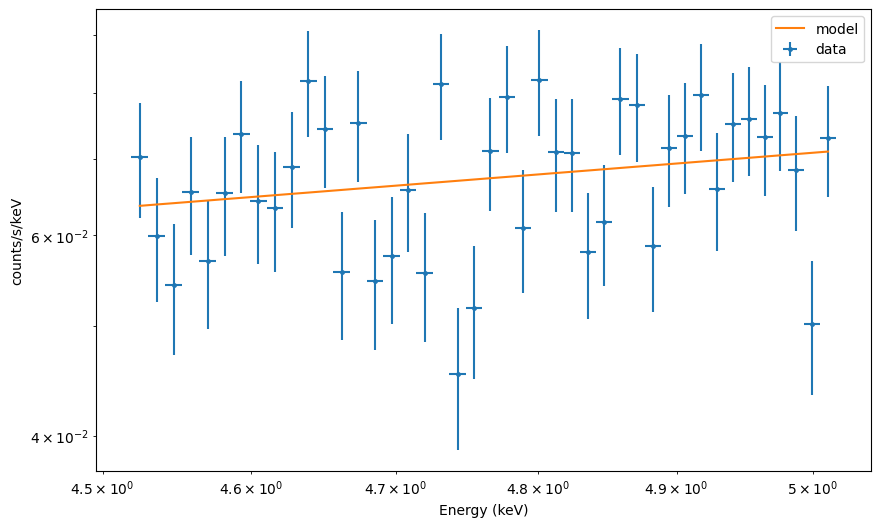

In [23]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

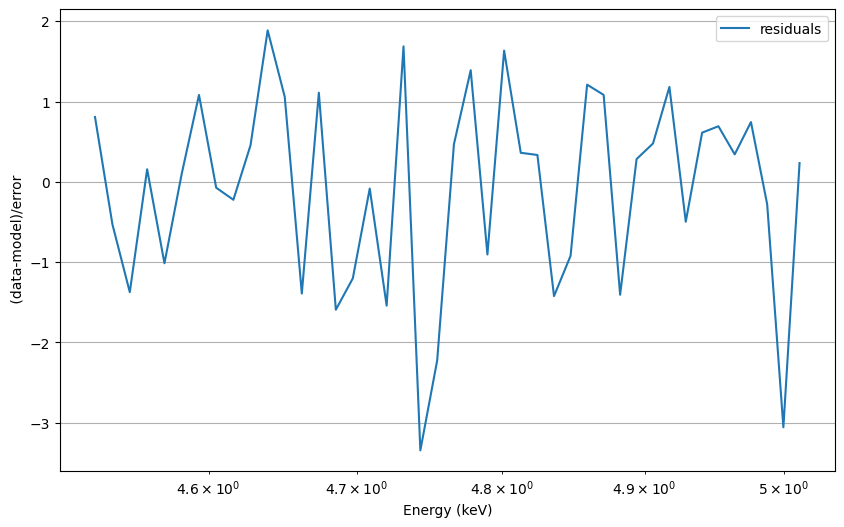

In [24]:
ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.plot(energies,(rates-foldedmodel)/errors,label='residuals')
#ax.axhline(y=-3)
#ax.axhline(y=3)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r' (data-model)/error')
ax.set_xscale("log")
#ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  2


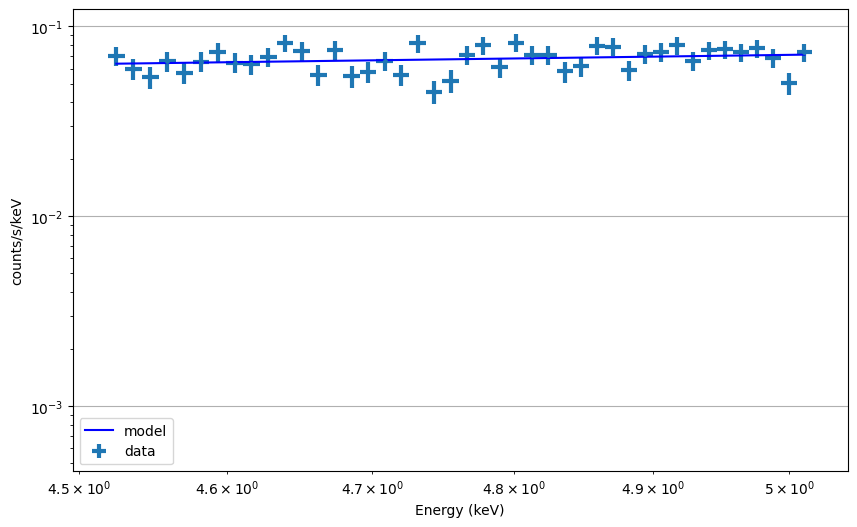

In [25]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]


fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
ax.plot(energiesTMi, foldedmodel,label='model',color='blue')
#ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)
#
for i in range(0,nAddComps):
#    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='orange')

ax.plot(energiesTMi, modelcomptot,label='',linestyle='-', marker='',color='green',linewidth=3.0)


ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.01,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()


#data = np.column_stack([energies,modelcomp[1][:], modelcomp[2][:], modelcomp[3][:]])
#datafile_path = "AstroComponents_APEC_APEC_PL.txt"
#np.savetxt(datafile_path , data) #fmt=['%6.2f','%6.2f', '%.2f', '%10.2f', '%10.2f']


In [26]:
print(modelcomp[0][:])
print(modelcomp[1][:])
print(modelcomp[2][:])
#print(modelcomp[3][:])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[5.61370547e-31 4.45600953e-31 3.35030151e-31 2.38710461e-31
 1.61643872e-31 1.03779620e-31 6.32893191e-32 3.65875694e-32
 2.00843820e-32 1.04556907e-32 5.17064587e-33 2.42755862e-33
 1.08420033e-33 4.60244174e-34 1.86257375e-34 7.17193706e-35
 2.63990687e-35 9.24708139e-36 3.10553245e-36 9.93701301e-37
 3.05039434e-37 8.67651483e-38 2.21614492e-38 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00]


IndexError: index 2 is out of bounds for axis 0 with size 2

NOW FIT ASTRO + DM